In [1]:
from io import StringIO
import os
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def load_metaphlan_matrix(pattern: str) -> pd.DataFrame:
    """
    Aggregate all MetaPhlAn output files in a directory into a sample-by-taxon abundance matrix.

    Args:
        output_dir: Path to the directory containing MetaPhlAn .txt output files.
        pattern:   Glob pattern to match filenames (default: '*.txt').

    Returns:
        A pandas DataFrame of shape (n_samples, n_taxa), where each row is a sample
        (derived from the filename) and each column is a clade_name string.
        Missing abundances are filled with 0.
    """
    # find all matching files
    file_paths = sorted(glob(pattern))
    dfs = []
    for path in file_paths:
        # derive sample name from filename, e.g. "sample1.txt" -> "sample1"
        sample = os.path.splitext(os.path.basename(path))[0]
        num_reads = -1
        with open(path, "r") as f:
            for line in f:
                if line.startswith("#"):
                    if line.endswith(" reads processed\n"):
                        num_reads = int(line.split()[0][1:])
                else:
                    break
            content = line + f.read()  # read the rest of the file into memory
            df = pd.read_csv(
                StringIO(content),
                sep="\t",
                comment="#",  # skip any lines beginning with '#'
                header=None,
                names=["clade_name", "ncbi_tax_id", sample, "additional_species"],
            )
        assert df["clade_name"].is_unique
        # index by clade_name so we can merge on index
        dfs.append((df.set_index("clade_name")[sample] * num_reads))

    # concatenate all on columns, fill missing with 0
    merged = pd.concat(dfs, axis=1).fillna(0)
    # Ideally all elements are close to a non-negative integer, but for very big values
    # the integer cannot be perfectly recovered due to floating-point precision.
    # check_all_close_to_nonneg_int(merged)
    merged = merged.round().astype(int)

    # transpose so rows = samples, columns = taxa
    return merged.transpose()


def check_all_close_to_nonneg_int(df: pd.DataFrame, tol: float = 1e-3) -> None:
    """
    Check whether all elements in the DataFrame are close to non-negative integers.

    Args:
        df: A pandas DataFrame of numeric values.
        tol: Allowed absolute tolerance for deviation from integers (default: 1e-6).

    Returns:
        True if all elements are within `tol` of a non-negative integer (≥ 0), else False.
    """
    values = df.values
    close_to_int = np.abs(values - np.round(values)) <= tol
    non_negative = values >= 0
    num_bad = np.sum(~(close_to_int & non_negative))
    if num_bad:
        raise ValueError(
            f"{num_bad} values in the DataFrame are not close to non-negative integers."
        )


def aggregate_by_rank(matrix: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """
    Aggregate a sample x taxon DataFrame at each common taxonomic rank.

    Args:
        matrix: DataFrame where
            - index = sample names
            - columns = full MetaPhlAn clade strings
              (e.g. "k__Bacteria|p__Firmicutes|c__Bacilli|…")

    Returns:
        A dict mapping each rank name ("kingdom", "phylum", …, "species")
        to a DataFrame aggregated at that rank:
            - index = samples
            - columns = unique clades at that rank
            - values = summed abundances
    """
    # Define the prefix→rank mapping
    rank_prefixes: dict[str, str] = {
        "k__": "kingdom",
        "p__": "phylum",
        "c__": "class",
        "o__": "order",
        "f__": "family",
        "g__": "genus",
        "s__": "species",
    }

    tables_by_rank: dict[str, pd.DataFrame] = {}
    for prefix, rank in rank_prefixes.items():
        # build a mapping from each full clade to its name at this rank
        def extract(clade: str) -> str:
            parts = clade.split("|")
            if parts[-1].startswith(prefix):
                return parts[-1]
            # if no assignment at this rank, lump into “unclassified”
            return f"{prefix}unclassified"

        # rename columns to their rank-level clade
        renamed = matrix.rename(columns={col: extract(col) for col in matrix.columns})
        # sum up columns with identical names
        aggregated = (
            renamed.transpose()
            .groupby(level=0)
            .sum()
            .transpose()
            .drop(f"{prefix}unclassified", axis=1, errors="ignore")
        )
        aggregated[f"{prefix}unclassified"] = renamed.sum(axis=1) - aggregated.sum(
            axis=1
        )

        tables_by_rank[rank] = aggregated

    return tables_by_rank


# Usage example:
# >>> tables = aggregate_by_rank(matrix)
# >>> tables["phylum"].shape    # (n_samples, n_phyla)
# >>> tables["genus"].iloc[:3,:5]


In [3]:
def rename_sample(name: str) -> str:
    if name == "SUB2h1":
        name = "SUB2k"
    elif name == "SUB2h2":
        name = "SUB2h"
    elif name == "SUB7a1":
        name = "SUB7a"
    elif name == "SUB7a2":
        name = "SUB6a"
    elif name == "SUB18a1":
        name = "SUB18a"
    elif name == "SUB18a2":
        name = "SUB19a"
    
    name = name.replace("SUB", "")
    # append 0 if name is a single digit
    name = name.zfill(3).upper()

    return name

In [8]:
count = load_metaphlan_matrix("./metaphlan/*.txt")
count.index = count.index.map(rename_sample)
level2count = aggregate_by_rank(count)
count.to_csv("read_count_metaphlan.tsv", sep="\t")
count

clade_name,UNCLASSIFIED,k__Bacteria,k__Bacteria|p__Firmicutes,k__Bacteria|p__Actinobacteria,k__Bacteria|p__Proteobacteria,k__Bacteria|p__Firmicutes|c__Bacilli,k__Bacteria|p__Actinobacteria|c__Actinomycetia,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria,k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Corynebacteriales,...,k__Bacteria|p__Bacteroidota|c__Flavobacteriia|o__Flavobacteriales|f__Flavobacteriaceae|g__Myroides|s__Myroides_injenensis,k__Bacteria|p__Bacteroidota|c__Flavobacteriia|o__Flavobacteriales|f__Flavobacteriaceae|g__Myroides|s__Myroides_injenensis|t__SGB28079,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria|o__Xanthomonadales|f__Xanthomonadaceae|g__Stenotrophomonas|s__Stenotrophomonas_maltophilia|t__SGB12453,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria|o__Enterobacterales|f__Enterobacteriaceae|g__Pluralibacter,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria|o__Enterobacterales|f__Enterobacteriaceae|g__Pluralibacter|s__Pluralibacter_gergoviae,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria|o__Enterobacterales|f__Enterobacteriaceae|g__Pluralibacter|s__Pluralibacter_gergoviae|t__SGB10111,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Enterococcaceae|g__Enterococcus|s__Enterococcus_raffinosus,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Corynebacteriales|f__Corynebacteriaceae|g__Corynebacterium|s__Corynebacterium_resistens,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Enterococcaceae|g__Enterococcus|s__Enterococcus_raffinosus|t__SGB7930,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Corynebacteriales|f__Corynebacteriaceae|g__Corynebacterium|s__Corynebacterium_resistens|t__SGB17040
10A,2142800,13727200,10041699,3516579,168922,10041699,3516579,168922,10041699,3516579,...,0,0,0,0,0,0,0,0,0,0
10B,496000,5543000,98898,1962780,3481322,98898,1962780,3481322,98898,1962780,...,0,0,0,0,0,0,0,0,0,0
10C,7708500,10622500,10622500,0,0,10622500,0,0,10622500,0,...,0,0,0,0,0,0,0,0,0,0
11A,1530200,4835300,1775625,3059675,0,1775625,3059675,0,1775625,250569,...,0,0,0,0,0,0,0,0,0,0
11B,92077202,329481598,319374540,3402393,6704669,319374540,3402393,6704669,319374540,563055,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
08B,93500,2426900,0,0,2426900,0,0,2426900,0,0,...,0,0,0,0,0,0,0,0,0,0
09A,12285900,36049300,33207882,1947005,894413,33207882,1947005,894413,33207882,0,...,0,0,0,0,0,0,0,0,0,0
YQEBMETA20A,477800,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
YQEBMETA20B,0,107628000,90958963,187725,16481312,90958963,187725,16481312,90958963,187725,...,0,0,0,0,0,0,0,0,0,0


In [5]:
level2count["species"]

clade_name,s__Achromobacter_xylosoxidans,s__Acinetobacter_baumannii,s__Alcaligenes_faecalis,s__Bacillus_altitudinis,s__Brevibacterium_rongguiense,s__Citrobacter_amalonaticus,s__Citrobacter_braakii,s__Citrobacter_freundii,s__Citrobacter_sp_ku_bf4,s__Clostridium_symbiosum,...,s__Solobacterium_moorei,s__Staphylococcus_aureus,s__Staphylococcus_caprae,s__Staphylococcus_epidermidis,s__Staphylococcus_succinus,s__Stenotrophomonas_maltophilia,s__Streptococcus_agalactiae,s__Streptococcus_pyogenes,s__Winkia_neuii,s__unclassified
10A,0,0,0,0,0,0,0,0,0,0,...,0,10041699,0,0,0,0,0,0,0,98233200
10B,0,0,0,0,0,0,3399932,81391,0,0,...,0,98898,0,0,0,0,0,0,0,39297001
10C,0,0,0,0,0,0,0,0,0,0,...,0,10622500,0,0,0,0,0,0,0,82066000
11A,0,0,0,0,0,0,0,0,0,0,...,0,1775625,0,0,0,0,0,0,0,35377304
11B,0,0,0,0,0,0,0,0,0,0,...,0,319374540,0,0,0,0,0,0,0,2398448392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
08B,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,17081800
09A,0,0,0,0,0,0,0,0,0,0,...,0,33207882,0,0,0,0,0,0,0,264631000
YQEBMETA20A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,477800
YQEBMETA20B,0,0,0,0,0,0,0,0,0,0,...,0,90958963,0,0,0,0,0,0,0,753396000


In [6]:
rel_ab_s = (
    level2count["species"]
    .drop(columns=["s__unclassified"])
    .div(level2count["species"].drop(columns=["s__unclassified"]).sum(axis=1), axis=0)
).sort_index()
rel_ab_s

clade_name,s__Achromobacter_xylosoxidans,s__Acinetobacter_baumannii,s__Alcaligenes_faecalis,s__Bacillus_altitudinis,s__Brevibacterium_rongguiense,s__Citrobacter_amalonaticus,s__Citrobacter_braakii,s__Citrobacter_freundii,s__Citrobacter_sp_ku_bf4,s__Clostridium_symbiosum,...,s__Serratia_marcescens,s__Solobacterium_moorei,s__Staphylococcus_aureus,s__Staphylococcus_caprae,s__Staphylococcus_epidermidis,s__Staphylococcus_succinus,s__Stenotrophomonas_maltophilia,s__Streptococcus_agalactiae,s__Streptococcus_pyogenes,s__Winkia_neuii
01A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.949312,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01C,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.059577,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.016372,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01F,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000098,0.0,0.076708,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17I,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
YQEBMETA20A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YQEBMETA20B,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.845124,0.0,0.0,0.0,0.0,0.0,0.0,0.0


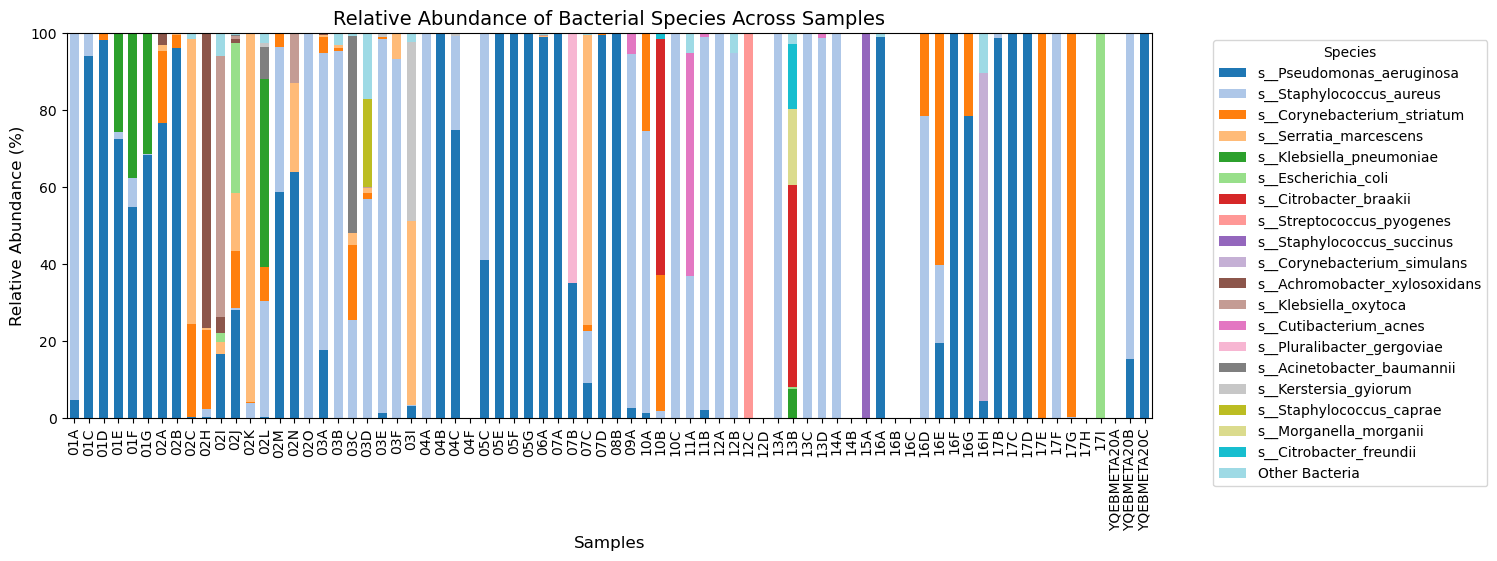

In [7]:
# Create a stacked bar plot for bacterial species abundance (rel_ab_s)
fig, ax = plt.subplots(figsize=(14, 5))

# Getting the top bacteria species for better visualization and legend readability
# Select top N species by mean abundance across samples
n_top_species = 19  # Adjust this number as needed
top_species = (
    rel_ab_s.mean()
    .sort_values(ascending=False)
    .head(n_top_species)
    .index.tolist()
)
other_species = [col for col in rel_ab_s.columns if col not in top_species]

# Create a modified dataframe with top species and an "Other" category
plot_df = rel_ab_s[top_species].copy()
plot_df["Other Bacteria"] = rel_ab_s[other_species].sum(axis=1)

# Set up colors - use a colorful palette for bacteria
colors = sns.color_palette("tab20", n_top_species + 1)  # +1 for the "Other" category

# Create the stacked bar plot
bottom = np.zeros(len(plot_df))
for i, species in enumerate(plot_df.columns):
    ax.bar(
        plot_df.index,
        plot_df[species] * 100,  # Convert to percentage
        bottom=bottom,
        label=species,
        color=colors[i],
        width=0.6,
    )
    bottom += plot_df[species].to_numpy() * 100

# Customize the plot
ax.set_xlabel("Samples", fontsize=12)
ax.set_ylabel("Relative Abundance (%)", fontsize=12)
ax.set_title("Relative Abundance of Bacterial Species Across Samples", fontsize=14)
ax.set_xticks(range(len(plot_df.index)))
ax.set_xticklabels(plot_df.index, rotation=90)
ax.set_ylim(0, 100)  # Set y-axis limit to 100%
ax.set_xlim(-0.5, len(plot_df.index) - 0.5)  # Adjust x-axis limits

# Create the legend first
ax.legend(title="Species", fontsize=9)

# Then move it
sns.move_legend(ax, loc="upper left", bbox_to_anchor=(1.05, 1))
fig.savefig("./figs/relab_sb_species_metaphlan.svg", bbox_inches='tight')